# Black Grouse 2030 Land-Use Scenario Project

## Stage 10: Agricultural Opportunity Costs

This notebook evaluates the agricultural land-use consequences of the four equal-area 2030 restoration scenarios.

The analysis will:

- Identify the BRP 2024 crop parcels affected by each restoration scenario.
- Calculate the restored area by crop type and agricultural category.
- Attach agricultural Standard Output coefficients to the affected crops.
- Estimate the annual agricultural output displaced by each scenario.
- Compare ecological restoration outcomes with agricultural opportunity costs.

The existing restoration masks generated in Stage 6 are reused. No new restoration scenarios are created in this notebook.

In [1]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = Path.cwd()

# Allow the notebook to run from either the project root
# or a notebooks subfolder.
if not (PROJECT_DIR / "data").exists():
    if (PROJECT_DIR.parent / "data").exists():
        PROJECT_DIR = PROJECT_DIR.parent
    else:
        raise FileNotFoundError(
            "The project data directory could not be found."
        )

EXTERNAL_DIR = PROJECT_DIR / "data" / "external"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Input files
# ---------------------------------------------------------

BRP_PATH = (
    EXTERNAL_DIR
    / "brp_gewaspercelen_2024_5km.gpkg"
)

RESTORATION_MASK_PATHS = {
    "Dispersed": (
        PROCESSED_DIR
        / "restoration_mask_dispersed.tif"
    ),
    "Patch enlargement": (
        PROCESSED_DIR
        / "restoration_mask_patch_enlargement.tif"
    ),
    "Connectivity focused": (
        PROCESSED_DIR
        / "restoration_mask_connectivity_focused.tif"
    ),
    "Integrated": (
        PROCESSED_DIR
        / "restoration_mask_integrated_low_matrix_pressure.tif"
    ),
}


# ---------------------------------------------------------
# Check that all required files exist
# ---------------------------------------------------------

required_files = {
    "BRP 2024 parcels": BRP_PATH,
    **RESTORATION_MASK_PATHS,
}

missing_files = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}

if missing_files:
    missing_text = "\n".join(
        f"- {name}: {path}"
        for name, path in missing_files.items()
    )

    raise FileNotFoundError(
        "The following required files are missing:\n"
        f"{missing_text}"
    )

print("All required input files were found.")


# ---------------------------------------------------------
# Load BRP 2024 agricultural parcels
# ---------------------------------------------------------

brp = gpd.read_file(BRP_PATH)

print(f"\nBRP file: {BRP_PATH.name}")
print(f"Number of parcels: {len(brp):,}")
print(f"CRS: {brp.crs}")
print(
    "Geometry types:",
    brp.geometry.geom_type.unique().tolist(),
)
print(
    "Missing geometries:",
    int(brp.geometry.isna().sum()),
)
print(
    "Empty geometries:",
    int(brp.geometry.is_empty.sum()),
)
print(
    "Invalid geometries:",
    int((~brp.geometry.is_valid).sum()),
)


# ---------------------------------------------------------
# Inspect the available attributes
# ---------------------------------------------------------

print("\nAvailable BRP columns:")

for column in brp.columns:
    print(f"- {column}")

display(
    brp.drop(columns="geometry")
       .head(10)
)

All required input files were found.

BRP file: brp_gewaspercelen_2024_5km.gpkg
Number of parcels: 64,469
CRS: EPSG:28992
Geometry types: ['MultiPolygon']
Missing geometries: 0
Empty geometries: 0
Invalid geometries: 0

Available BRP columns:
- id
- category
- gewas
- gewascode
- jaar
- status
- geometry


,id,category,gewas,gewascode,jaar,status
0,706548,Grasland,"Grasland, tijdelijk",266,2024,Definitief
1,508691,Landschapselement,Houtwal en houtsingel,2621,2024,Definitief
2,1140975,Grasland,"Grasland, blijvend",265,2024,Definitief
3,400584,Grasland,"Grasland, tijdelijk",266,2024,Definitief
4,230617,Grasland,"Grasland, tijdelijk",266,2024,Definitief
5,153212,Bouwland,"Mais, snij-",259,2024,Definitief
6,1036739,Grasland,"Grasland, blijvend",265,2024,Definitief
7,229646,Grasland,"Grasland, blijvend",265,2024,Definitief
8,153210,Landschapselement,Sloot,343,2024,Definitief
9,230619,Grasland,"Grasland, tijdelijk",266,2024,Definitief


In [2]:
from rasterio.features import shapes
from shapely.geometry import shape
from shapely.ops import unary_union


# ---------------------------------------------------------
# Validate BRP attributes
# ---------------------------------------------------------

if not (brp["jaar"] == 2024).all():
    raise ValueError(
        "The BRP dataset contains records from years other than 2024."
    )

if not (
    brp["status"]
    .astype(str)
    .str.lower()
    .eq("definitief")
    .all()
):
    raise ValueError(
        "The BRP dataset contains records that are not definitive."
    )

brp = brp.rename(columns={"id": "brp_id"}).copy()

print("BRP year and status validation passed.")


# ---------------------------------------------------------
# Convert one restoration raster to a dissolved geometry
# ---------------------------------------------------------

def restoration_mask_to_geometry(mask_path):

    with rasterio.open(mask_path) as src:

        mask_array = src.read(1)
        restoration_mask = mask_array == 1

        raster_crs = src.crs
        pixel_area_ha = (
            abs(src.res[0] * src.res[1]) / 10_000
        )

        restored_pixels = int(restoration_mask.sum())
        restored_area_ha = restored_pixels * pixel_area_ha

        geometries = [
            shape(geometry)
            for geometry, value in shapes(
                restoration_mask.astype("uint8"),
                mask=restoration_mask,
                transform=src.transform,
            )
            if value == 1
        ]

    if not geometries:
        raise ValueError(
            f"No restoration pixels were found in {mask_path.name}."
        )

    dissolved_geometry = unary_union(geometries)

    return {
        "geometry": dissolved_geometry,
        "crs": raster_crs,
        "restored_pixels": restored_pixels,
        "restored_area_ha": restored_area_ha,
    }


# ---------------------------------------------------------
# Intersect each restoration scenario with BRP parcels
# ---------------------------------------------------------

intersection_results = []
coverage_records = []

for scenario_name, mask_path in RESTORATION_MASK_PATHS.items():

    print(f"\nProcessing: {scenario_name}")

    restoration = restoration_mask_to_geometry(mask_path)

    if restoration["crs"] != brp.crs:
        raise ValueError(
            f"CRS mismatch for {scenario_name}: "
            f"{restoration['crs']} versus {brp.crs}"
        )

    restoration_geometry = restoration["geometry"]

    # Use the spatial index to select only nearby parcels.
    candidate_indices = brp.sindex.query(
        restoration_geometry,
        predicate="intersects",
    )

    affected = brp.iloc[
        np.unique(candidate_indices)
    ].copy()

    # Calculate the exact parcel area within restoration.
    affected["geometry"] = (
        affected.geometry
        .intersection(restoration_geometry)
    )

    affected = affected[
        (~affected.geometry.is_empty)
        & affected.geometry.notna()
    ].copy()

    affected["affected_area_ha"] = (
        affected.geometry.area / 10_000
    )

    affected = affected[
        affected["affected_area_ha"] > 0
    ].copy()

    affected["scenario"] = scenario_name

    intersection_results.append(affected)

    brp_overlap_area_ha = affected[
        "affected_area_ha"
    ].sum()

    restored_area_ha = restoration[
        "restored_area_ha"
    ]

    coverage_records.append(
        {
            "scenario": scenario_name,
            "restored_pixels": restoration[
                "restored_pixels"
            ],
            "restored_area_ha": restored_area_ha,
            "brp_overlap_area_ha": brp_overlap_area_ha,
            "area_without_brp_ha": (
                restored_area_ha - brp_overlap_area_ha
            ),
            "brp_coverage_percent": (
                brp_overlap_area_ha
                / restored_area_ha
                * 100
            ),
            "affected_brp_features": len(affected),
        }
    )


# ---------------------------------------------------------
# Combine all scenario intersections
# ---------------------------------------------------------

restoration_brp = gpd.GeoDataFrame(
    pd.concat(
        intersection_results,
        ignore_index=True,
    ),
    geometry="geometry",
    crs=brp.crs,
)

coverage_summary = pd.DataFrame(
    coverage_records
)


# ---------------------------------------------------------
# Summarise affected area by crop
# ---------------------------------------------------------

area_by_crop = (
    restoration_brp
    .groupby(
        [
            "scenario",
            "category",
            "gewas",
            "gewascode",
        ],
        as_index=False,
    )
    .agg(
        affected_area_ha=(
            "affected_area_ha",
            "sum",
        ),
        affected_features=(
            "brp_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "scenario",
            "affected_area_ha",
        ],
        ascending=[True, False],
    )
)

area_by_crop["affected_area_ha"] = (
    area_by_crop["affected_area_ha"]
    .round(4)
)

coverage_summary[
    [
        "restored_area_ha",
        "brp_overlap_area_ha",
        "area_without_brp_ha",
        "brp_coverage_percent",
    ]
] = coverage_summary[
    [
        "restored_area_ha",
        "brp_overlap_area_ha",
        "area_without_brp_ha",
        "brp_coverage_percent",
    ]
].round(4)


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

INTERSECTION_PATH = (
    PROCESSED_DIR
    / "restoration_brp_intersections.gpkg"
)

AREA_BY_CROP_PATH = (
    TABLES_DIR
    / "restoration_area_by_crop.csv"
)

COVERAGE_PATH = (
    TABLES_DIR
    / "restoration_brp_coverage_summary.csv"
)

restoration_brp.to_file(
    INTERSECTION_PATH,
    layer="restoration_brp_intersections",
    driver="GPKG",
)

area_by_crop.to_csv(
    AREA_BY_CROP_PATH,
    index=False,
)

coverage_summary.to_csv(
    COVERAGE_PATH,
    index=False,
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("\nBRP coverage by scenario:")
display(coverage_summary)

print("\nLargest affected crop areas:")
display(
    area_by_crop
    .groupby("scenario", group_keys=False)
    .head(10)
)

print("\nOutputs saved:")
print(f"- {INTERSECTION_PATH}")
print(f"- {AREA_BY_CROP_PATH}")
print(f"- {COVERAGE_PATH}")

BRP year and status validation passed.

Processing: Dispersed

Processing: Patch enlargement

Processing: Connectivity focused

Processing: Integrated

BRP coverage by scenario:


,scenario,restored_pixels,restored_area_ha,brp_overlap_area_ha,area_without_brp_ha,brp_coverage_percent,affected_brp_features
0,Dispersed,18649,1165.5625,1021.9611,143.6014,87.6796,18032
1,Patch enlargement,18649,1165.5625,906.1933,259.3692,77.7473,7564
2,Connectivity focused,18649,1165.5625,989.1929,176.3696,84.8683,1977
3,Integrated,18649,1165.5625,1075.9895,89.5730,92.3150,2522



Largest affected crop areas:


,scenario,category,gewas,gewascode,affected_area_ha,affected_features
36,Connectivity focused,Grasland,"Grasland, blijvend",265,388.7050,575
23,Connectivity focused,Bouwland,"Mais, snij-",259,186.2526,179
39,Connectivity focused,Grasland,"Grasland, tijdelijk",266,160.3770,145
0,Connectivity focused,Bouwland,"Aardappelen, consumptie",2014,38.9961,6
2,Connectivity focused,Bouwland,"Aardappelen, zetmeel",2017,38.9824,12
26,Connectivity focused,Bouwland,"Rogge, korrelgewas",7130,34.6314,21
22,Connectivity focused,Bouwland,"Mais, korrel-",316,16.4558,16
30,Connectivity focused,Bouwland,"Uien, gele zaai-",6660,14.4451,9
4,Connectivity focused,Bouwland,"Bieten, suiker-",256,11.0860,4
1,Connectivity focused,Bouwland,"Aardappelen, poot NAK",2015,7.9400,5



Outputs saved:
- C:\Users\smit1\BlackGrouse_2030\data\processed\restoration_brp_intersections.gpkg
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\restoration_area_by_crop.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\restoration_brp_coverage_summary.csv


In [3]:
# ---------------------------------------------------------
# Assign Dutch Standard Output coefficients
# ---------------------------------------------------------

def assign_so_coefficient(category, crop_name):

    category_text = str(category).strip().lower()
    crop_text = str(crop_name).strip().lower()

    # Registered landscape elements do not generate
    # agricultural Standard Output.
    if category_text == "landschapselement":
        return 0.0, "Non-productive landscape element"

    # Land without agricultural production.
    zero_output_terms = [
        "groene braak",
        "onbeteelde grond",
        "gewasresten",
        "groenbemester",
        "vanggewas",
        "teeltverbod",
        "bosrand",
        "hoofdfunctie natuur",
    ]

    if any(term in crop_text for term in zero_output_terms):
        return 0.0, "WUR SO-2020: no production"

    # Grassland and forage crops
    if "grasland, blijvend" in crop_text:
        return 1250.0, "WUR SO-2020"

    if "grasland, tijdelijk" in crop_text:
        return 1250.0, "WUR SO-2020"

    if "grasland, natuurlijk" in crop_text:
        return 374.0, "WUR SO-2020"

    if "mais, snij" in crop_text:
        return 1800.0, "WUR SO-2020"

    if "mais, korrel" in crop_text:
        return 1680.0, "WUR SO-2020"

    if "mais, corncob mix" in crop_text:
        return 1430.0, "WUR SO-2020"

    if "mais, energie" in crop_text:
        return 1170.0, "WUR SO-2020"

    if "luzerne" in crop_text:
        return 1050.0, "WUR SO-2020"

    if "snijrogge" in crop_text:
        return 1250.0, "WUR SO-2020"

    # Potatoes
    if "aardappelen, consumptie" in crop_text:
        return 8620.0, "WUR SO-2020"

    if "aardappelen, zetmeel" in crop_text:
        return 4030.0, "WUR SO-2020"

    if (
        "aardappelen, poot nak" in crop_text
        or "pootaardappelen nak" in crop_text
    ):
        return 11700.0, "WUR SO-2020"

    if (
        "aardappelen, poot tbm" in crop_text
        or "pootaardappelen tbm" in crop_text
    ):
        return 6000.0, "WUR SO-2020"

    # Cereals
    if "rogge, korrel" in crop_text:
        return 1160.0, "WUR SO-2020"

    if "wintertarwe" in crop_text:
        return 2390.0, "WUR SO-2020"

    if "zomertarwe" in crop_text:
        return 1810.0, "WUR SO-2020"

    if "wintergerst" in crop_text:
        return 1950.0, "WUR SO-2020"

    if "zomergerst" in crop_text:
        return 1530.0, "WUR SO-2020"

    if "spelt" in crop_text:
        return 1350.0, "WUR SO-2020"

    if "triticale" in crop_text:
        return 1280.0, "WUR SO-2020"

    if "haver" in crop_text:
        return 1630.0, "WUR SO-2020"

    # Sugar beet and onions
    if "bieten, suiker" in crop_text:
        return 3440.0, "WUR SO-2020"

    if (
        "uien, gele zaai" in crop_text
        or "uien, rode zaai" in crop_text
    ):
        return 8100.0, "WUR SO-2020"

    # Flower bulbs
    flower_bulb_coefficients = {
        "lelie": 36000.0,
        "tulp": 31600.0,
        "hyacint": 28900.0,
        "krokus": 28100.0,
        "dahlia": 27500.0,
        "gladiool": 27500.0,
        "iris": 27500.0,
        "narcis": 24000.0,
        "zantedeschia": 36000.0,
    }

    if "bloembollen en -knollen" in crop_text:
        for crop_term, coefficient in flower_bulb_coefficients.items():
            if crop_term in crop_text:
                return coefficient, "WUR SO-2020"

    # Other recognised crops
    if "agrarisch natuurmengsel" in crop_text:
        return 4360.0, "WUR SO-2020"

    return np.nan, "Unmapped"


# ---------------------------------------------------------
# Apply coefficients
# ---------------------------------------------------------

so_assignment = area_by_crop.apply(
    lambda row: assign_so_coefficient(
        row["category"],
        row["gewas"],
    ),
    axis=1,
    result_type="expand",
)

area_by_crop[
    [
        "so_euro_per_ha_year",
        "coefficient_source",
    ]
] = so_assignment

area_by_crop["annual_standard_output_euro"] = (
    area_by_crop["affected_area_ha"]
    * area_by_crop["so_euro_per_ha_year"]
)


# ---------------------------------------------------------
# Inspect unmapped crops
# ---------------------------------------------------------

unmapped_crops = (
    area_by_crop[
        area_by_crop["so_euro_per_ha_year"].isna()
    ]
    .groupby(
        [
            "category",
            "gewas",
            "gewascode",
        ],
        as_index=False,
    )
    .agg(
        affected_area_ha=(
            "affected_area_ha",
            "sum",
        )
    )
    .sort_values(
        "affected_area_ha",
        ascending=False,
    )
)

print("Largest crop classes without an SO coefficient:")
display(unmapped_crops.head(25))


# ---------------------------------------------------------
# Mapping completeness by scenario
# ---------------------------------------------------------

area_by_crop["coefficient_mapped"] = (
    area_by_crop["so_euro_per_ha_year"].notna()
)

mapping_summary = (
    area_by_crop
    .groupby("scenario", as_index=False)
    .agg(
        brp_overlap_area_ha=(
            "affected_area_ha",
            "sum",
        ),
        coefficient_mapped_area_ha=(
            "affected_area_ha",
            lambda values: values[
                area_by_crop.loc[
                    values.index,
                    "coefficient_mapped",
                ]
            ].sum(),
        ),
        annual_standard_output_euro=(
            "annual_standard_output_euro",
            "sum",
        ),
    )
)

mapping_summary["unmapped_area_ha"] = (
    mapping_summary["brp_overlap_area_ha"]
    - mapping_summary["coefficient_mapped_area_ha"]
)

mapping_summary["coefficient_coverage_percent"] = (
    mapping_summary["coefficient_mapped_area_ha"]
    / mapping_summary["brp_overlap_area_ha"]
    * 100
)

mapping_summary[
    [
        "brp_overlap_area_ha",
        "coefficient_mapped_area_ha",
        "unmapped_area_ha",
        "annual_standard_output_euro",
        "coefficient_coverage_percent",
    ]
] = mapping_summary[
    [
        "brp_overlap_area_ha",
        "coefficient_mapped_area_ha",
        "unmapped_area_ha",
        "annual_standard_output_euro",
        "coefficient_coverage_percent",
    ]
].round(2)

print("\nSO coefficient coverage:")
display(mapping_summary)

Largest crop classes without an SO coefficient:


,category,gewas,gewascode,affected_area_ha
22,Bouwland,"Gerst, zomer-",236,18.5856
57,Bouwland,"Tarwe, winter-",233,15.0022
70,Natuurterrein,Natuurterreinen (incl. heide),335,12.6065
24,Bouwland,"Granen, overig",2652,10.6919
21,Bouwland,"Gerst, winter-",235,9.9294
37,Bouwland,"Lelie, overige bloemkwekerijgewassen",979,9.8228
67,Bouwland,Zoete aardappelen,6632,8.1151
40,Bouwland,Miscanthus (olifantsgras),516,6.6121
8,Bouwland,"Bieten, voeder-",257,5.9470
59,Bouwland,"Uien, poot en plant, 1e jaars",1932,5.7436



SO coefficient coverage:


,scenario,brp_overlap_area_ha,coefficient_mapped_area_ha,annual_standard_output_euro,unmapped_area_ha,coefficient_coverage_percent
0,Connectivity focused,989.19,946.54,2018774.51,42.65,95.69
1,Dispersed,1021.96,990.95,1774292.68,31.02,96.97
2,Integrated,1075.99,1034.35,1996474.61,41.64,96.13
3,Patch enlargement,906.19,862.57,1446599.01,43.62,95.19


In [4]:
# ---------------------------------------------------------
# Improve coefficient mapping
# ---------------------------------------------------------

area_by_crop["coefficient_method"] = np.where(
    area_by_crop["so_euro_per_ha_year"].notna(),
    "Direct crop match",
    "Unmapped",
)


def assign_additional_coefficient(category, crop_name):

    category_text = str(category).strip().lower()
    crop_text = str(crop_name).strip().lower()

    # Exact crop-name variants present in BRP
    exact_patterns = {
        "gerst, zomer-": 1530.0,
        "gerst, winter-": 1950.0,
        "tarwe, winter-": 2390.0,
        "tarwe, zomer-": 1810.0,
    }

    for pattern, coefficient in exact_patterns.items():
        if pattern in crop_text:
            return (
                coefficient,
                "WUR SO-2020",
                "Direct crop match",
            )

    # Areas without marketed agricultural production
    if category_text == "natuurterrein":
        return (
            0.0,
            "Non-productive land assumption",
            "Zero-output class",
        )

    if (
        category_text == "overige"
        and "bos" in crop_text
    ):
        return (
            0.0,
            "Non-productive land assumption",
            "Zero-output class",
        )

    # Transparent proxies for clearly related crop types
    if "granen, overig" in crop_text:
        return (
            1530.0,
            "Proxy: summer barley",
            "Related-crop proxy",
        )

    if "lelie" in crop_text:
        return (
            36000.0,
            "Proxy: lily production",
            "Related-crop proxy",
        )

    if "zoete aardappelen" in crop_text:
        return (
            8620.0,
            "Proxy: consumption potatoes",
            "Related-crop proxy",
        )

    if "miscanthus" in crop_text:
        return (
            1170.0,
            "Proxy: energy maize",
            "Related-crop proxy",
        )

    if "bieten, voeder" in crop_text:
        return (
            1800.0,
            "Proxy: forage maize",
            "Related-crop proxy",
        )

    if "uien, poot en plant" in crop_text:
        return (
            8100.0,
            "Proxy: field onions",
            "Related-crop proxy",
        )

    if (
        "soedangras" in crop_text
        or "sorghum" in crop_text
    ):
        return (
            1800.0,
            "Proxy: forage maize",
            "Related-crop proxy",
        )

    if (
        "wikke" in crop_text
        or "italiaans raaigras" in crop_text
    ):
        return (
            1050.0,
            "Proxy: forage crop",
            "Related-crop proxy",
        )

    return np.nan, "Unmapped", "Unmapped"


unmapped_mask = area_by_crop[
    "so_euro_per_ha_year"
].isna()

additional_assignments = area_by_crop.loc[
    unmapped_mask
].apply(
    lambda row: assign_additional_coefficient(
        row["category"],
        row["gewas"],
    ),
    axis=1,
    result_type="expand",
)

additional_assignments.columns = [
    "new_coefficient",
    "new_source",
    "new_method",
]

area_by_crop.loc[
    unmapped_mask,
    "so_euro_per_ha_year",
] = additional_assignments[
    "new_coefficient"
].values

area_by_crop.loc[
    unmapped_mask,
    "coefficient_source",
] = additional_assignments[
    "new_source"
].values

area_by_crop.loc[
    unmapped_mask,
    "coefficient_method",
] = additional_assignments[
    "new_method"
].values


# ---------------------------------------------------------
# Calculate area-weighted category-median proxies
# for any remaining rare crop classes
# ---------------------------------------------------------

def weighted_median(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cumulative_weight = np.cumsum(weights)

    cutoff = weights.sum() / 2

    return float(
        values[
            np.searchsorted(
                cumulative_weight,
                cutoff,
            )
        ]
    )


mapped_for_proxy = area_by_crop[
    area_by_crop["so_euro_per_ha_year"].notna()
].copy()

category_proxy_values = {}

for category_name, group in mapped_for_proxy.groupby(
    "category"
):

    category_proxy_values[category_name] = weighted_median(
        group["so_euro_per_ha_year"],
        group["affected_area_ha"],
    )


# Bouwland is the main category requiring fallback values.
if "Bouwland" not in category_proxy_values:
    raise ValueError(
        "A Bouwland proxy coefficient could not be calculated."
    )


remaining_unmapped = area_by_crop[
    "so_euro_per_ha_year"
].isna()

for row_index in area_by_crop[
    remaining_unmapped
].index:

    category_name = area_by_crop.loc[
        row_index,
        "category",
    ]

    proxy_value = category_proxy_values.get(
        category_name,
        category_proxy_values["Bouwland"],
    )

    area_by_crop.loc[
        row_index,
        "so_euro_per_ha_year",
    ] = proxy_value

    area_by_crop.loc[
        row_index,
        "coefficient_source",
    ] = (
        f"Area-weighted median proxy for "
        f"{category_name}"
    )

    area_by_crop.loc[
        row_index,
        "coefficient_method",
    ] = "Category-median proxy"


# ---------------------------------------------------------
# Recalculate agricultural output
# ---------------------------------------------------------

area_by_crop["annual_standard_output_euro"] = (
    area_by_crop["affected_area_ha"]
    * area_by_crop["so_euro_per_ha_year"]
)

area_by_crop["annual_standard_output_euro"] = (
    area_by_crop["annual_standard_output_euro"]
    .round(2)
)


# ---------------------------------------------------------
# Create scenario-level opportunity-cost table
# ---------------------------------------------------------

scenario_costs = (
    area_by_crop
    .groupby(
        "scenario",
        as_index=False,
    )
    .agg(
        brp_covered_area_ha=(
            "affected_area_ha",
            "sum",
        ),
        annual_standard_output_euro=(
            "annual_standard_output_euro",
            "sum",
        ),
        crop_classes=(
            "gewascode",
            "nunique",
        ),
    )
)

scenario_costs = coverage_summary.merge(
    scenario_costs,
    on="scenario",
    how="left",
)

scenario_costs[
    "annual_output_per_restored_ha_euro"
] = (
    scenario_costs[
        "annual_standard_output_euro"
    ]
    / scenario_costs["restored_area_ha"]
)

scenario_costs[
    "annual_output_per_brp_ha_euro"
] = (
    scenario_costs[
        "annual_standard_output_euro"
    ]
    / scenario_costs["brp_covered_area_ha"]
)

numeric_columns = [
    "restored_area_ha",
    "brp_overlap_area_ha",
    "area_without_brp_ha",
    "brp_coverage_percent",
    "brp_covered_area_ha",
    "annual_standard_output_euro",
    "annual_output_per_restored_ha_euro",
    "annual_output_per_brp_ha_euro",
]

scenario_costs[numeric_columns] = (
    scenario_costs[numeric_columns]
    .round(2)
)


# ---------------------------------------------------------
# Validate complete coefficient assignment
# ---------------------------------------------------------

remaining_unmapped_count = int(
    area_by_crop[
        "so_euro_per_ha_year"
    ].isna().sum()
)

if remaining_unmapped_count != 0:
    raise ValueError(
        f"{remaining_unmapped_count} crop records "
        "remain without coefficients."
    )

method_summary = (
    area_by_crop
    .groupby(
        [
            "scenario",
            "coefficient_method",
        ],
        as_index=False,
    )
    .agg(
        affected_area_ha=(
            "affected_area_ha",
            "sum",
        )
    )
)

method_summary["affected_area_ha"] = (
    method_summary["affected_area_ha"]
    .round(2)
)


# ---------------------------------------------------------
# Save Notebook 10 result tables
# ---------------------------------------------------------

AREA_WITH_SO_PATH = (
    TABLES_DIR
    / "restoration_area_by_crop_with_so.csv"
)

SCENARIO_COST_PATH = (
    TABLES_DIR
    / "scenario_agricultural_opportunity_costs.csv"
)

METHOD_SUMMARY_PATH = (
    TABLES_DIR
    / "so_coefficient_method_summary.csv"
)

area_by_crop.to_csv(
    AREA_WITH_SO_PATH,
    index=False,
)

scenario_costs.to_csv(
    SCENARIO_COST_PATH,
    index=False,
)

method_summary.to_csv(
    METHOD_SUMMARY_PATH,
    index=False,
)


print("Coefficient assignment by method:")
display(method_summary)

print("\nScenario agricultural opportunity costs:")
display(
    scenario_costs[
        [
            "scenario",
            "restored_area_ha",
            "brp_coverage_percent",
            "annual_standard_output_euro",
            "annual_output_per_restored_ha_euro",
            "annual_output_per_brp_ha_euro",
            "crop_classes",
        ]
    ]
)

print("\nOutputs saved:")
print(f"- {AREA_WITH_SO_PATH}")
print(f"- {SCENARIO_COST_PATH}")
print(f"- {METHOD_SUMMARY_PATH}")

Coefficient assignment by method:


,scenario,coefficient_method,affected_area_ha
0,Connectivity focused,Category-median proxy,5.73
1,Connectivity focused,Direct crop match,962.31
2,Connectivity focused,Related-crop proxy,17.63
3,Connectivity focused,Zero-output class,3.51
4,Dispersed,Category-median proxy,9.99
5,Dispersed,Direct crop match,1004.53
6,Dispersed,Related-crop proxy,6.61
7,Dispersed,Zero-output class,0.83
8,Integrated,Category-median proxy,13.25
9,Integrated,Direct crop match,1043.93



Scenario agricultural opportunity costs:


,scenario,restored_area_ha,brp_coverage_percent,annual_standard_output_euro,annual_output_per_restored_ha_euro,annual_output_per_brp_ha_euro,crop_classes
0,Dispersed,1165.56,87.68,1847400.57,1584.99,1807.70,121
1,Patch enlargement,1165.56,77.75,1569796.56,1346.81,1732.30,93
2,Connectivity focused,1165.56,84.87,2252302.79,1932.37,2276.91,58
3,Integrated,1165.56,92.32,2246921.42,1927.76,2088.24,66



Outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\restoration_area_by_crop_with_so.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_agricultural_opportunity_costs.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\so_coefficient_method_summary.csv


Notebook 10 final validation passed.


,rank_lowest_cost,scenario,restored_area_ha,brp_coverage_percent,annual_output_displaced_euro,output_displaced_per_restored_ha_euro
0,1,Patch enlargement,1165.56,77.75,1569796.56,1346.81
1,2,Dispersed,1165.56,87.68,1847400.57,1584.99
2,3,Integrated,1165.56,92.32,2246921.42,1927.76
3,4,Connectivity focused,1165.56,84.87,2252302.79,1932.37


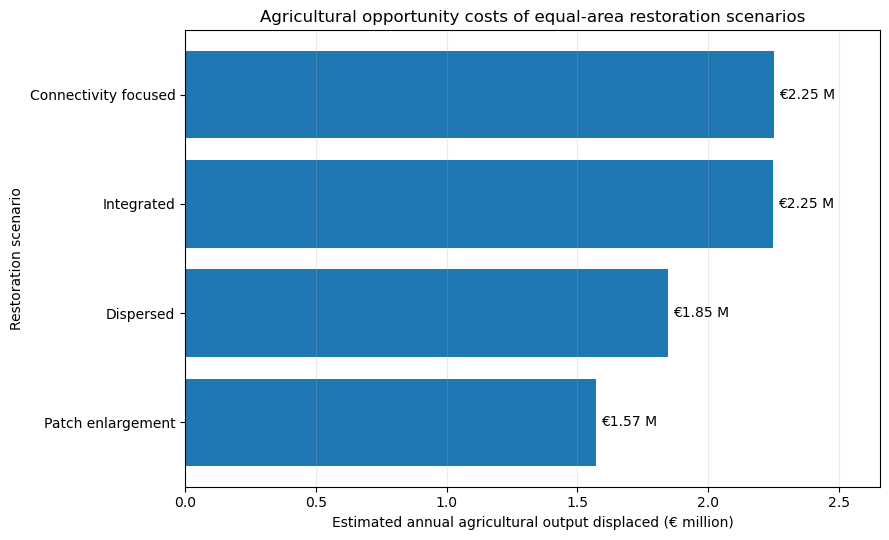


Final outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_economic_cost_ranking.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\figures\scenario_agricultural_opportunity_costs.png


In [5]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Rank scenarios by agricultural opportunity cost
# ---------------------------------------------------------

scenario_costs = scenario_costs.sort_values(
    "annual_standard_output_euro",
    ascending=True,
).reset_index(drop=True)

scenario_costs["economic_cost_rank"] = (
    scenario_costs[
        "annual_standard_output_euro"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

scenario_costs["annual_standard_output_million_euro"] = (
    scenario_costs[
        "annual_standard_output_euro"
    ] / 1_000_000
)


# ---------------------------------------------------------
# Final validation
# ---------------------------------------------------------

if len(scenario_costs) != 4:
    raise ValueError(
        "The final economic comparison must contain four scenarios."
    )

if scenario_costs[
    "annual_standard_output_euro"
].isna().any():
    raise ValueError(
        "Missing agricultural opportunity-cost values."
    )

if not (
    scenario_costs["restored_pixels"] == 18_649
).all():
    raise ValueError(
        "The scenarios do not contain equal restoration areas."
    )

print("Notebook 10 final validation passed.")


# ---------------------------------------------------------
# Display final economic ranking
# ---------------------------------------------------------

economic_ranking = scenario_costs[
    [
        "economic_cost_rank",
        "scenario",
        "restored_area_ha",
        "brp_coverage_percent",
        "annual_standard_output_euro",
        "annual_output_per_restored_ha_euro",
    ]
].copy()

economic_ranking = economic_ranking.rename(
    columns={
        "economic_cost_rank": "rank_lowest_cost",
        "annual_standard_output_euro": (
            "annual_output_displaced_euro"
        ),
        "annual_output_per_restored_ha_euro": (
            "output_displaced_per_restored_ha_euro"
        ),
    }
)

display(economic_ranking)


# ---------------------------------------------------------
# Create portfolio figure
# ---------------------------------------------------------

figure_data = scenario_costs.sort_values(
    "annual_standard_output_euro",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    figure_data["scenario"],
    figure_data[
        "annual_standard_output_million_euro"
    ],
)

ax.set_xlabel(
    "Estimated annual agricultural output displaced (€ million)"
)

ax.set_ylabel("Restoration scenario")

ax.set_title(
    "Agricultural opportunity costs of equal-area restoration scenarios"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

for bar, value in zip(
    bars,
    figure_data[
        "annual_standard_output_million_euro"
    ],
):
    ax.text(
        value + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"€{value:.2f} M",
        va="center",
    )

ax.set_xlim(
    0,
    figure_data[
        "annual_standard_output_million_euro"
    ].max() * 1.18,
)

plt.tight_layout()

FIGURE_PATH = (
    FIGURES_DIR
    / "scenario_agricultural_opportunity_costs.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------
# Save final ranked table
# ---------------------------------------------------------

FINAL_RANKING_PATH = (
    TABLES_DIR
    / "scenario_economic_cost_ranking.csv"
)

economic_ranking.to_csv(
    FINAL_RANKING_PATH,
    index=False,
)

print("\nFinal outputs saved:")
print(f"- {FINAL_RANKING_PATH}")
print(f"- {FIGURE_PATH}")